# FEC Contribution Analysis

Aggregates FEC Schedule A data for a company, joins with PAC party lookups,
and visualizes political contribution patterns using the **60% rule**:
a contributor is assigned a party only if ≥ 60% of their total donations
went to that party.

Data sources:
- `csv/AllPacs.xslx.csv` — PAC party affiliation, joined on `committee_id`
- `csv/Aristotle1.xlsx.csv` — alternate party lookup, joined on `committee_id = Code`

In [1]:
# Path to the company FEC CSV — change this to analyze a different company
CSV_PATH = './csv/TractorSupplyFECr.csv'

In [2]:
import os
import re
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

%matplotlib inline

# Resolve paths from project root whether launched from notebooks/ or project root
_here = Path.cwd()
if _here.name == 'notebooks':
    os.chdir(_here.parent)

In [3]:
company_name = re.sub(r'FECr?$', '', Path(CSV_PATH).stem, flags=re.IGNORECASE).upper()

fec       = pd.read_csv(CSV_PATH)
allpacs   = pd.read_csv('./csv/AllPacs.xslx.csv')
aristotle = pd.read_csv('./csv/Aristotle1.xlsx.csv')

con = duckdb.connect(':memory:')

print(f'Company : {company_name}')
print(f'Rows    : {len(fec):,}')
fec.head(3)

Company : TRACTORSUPPLY
Rows    : 3,713


,committee_id,committee_name,report_year,report_type,image_number,line_number,transaction_id,file_number,committee_name1,entity_type,...,filing_form,link_id,is_individual,memo_text,two_year_transaction_period,schedule_type,increased_limit,sub_id,pdf_url,line_number_label
0,C00618371,TRUMP MAKE AMERICA GREAT AGAIN COMMITTEE,2019.0,Q2,2.019072e+17,11AI,SA11AI.146631,1340707.0,NaN,IND,...,F3X,4.071520e+18,t,NaN,2020.0,SA,NaN,4.071720e+18,http://docquery.fec.gov/cgi-bin/fecimg/?201907...,Contributions From Individuals/Persons Other T...
1,C00618371,TRUMP MAKE AMERICA GREAT AGAIN COMMITTEE,2019.0,Q2,2.019072e+17,11AI,SA11AI.146632,1340707.0,NaN,IND,...,F3X,4.071520e+18,t,NaN,2020.0,SA,NaN,4.071720e+18,http://docquery.fec.gov/cgi-bin/fecimg/?201907...,Contributions From Individuals/Persons Other T...
2,C00618371,TRUMP MAKE AMERICA GREAT AGAIN COMMITTEE,2019.0,Q2,2.019072e+17,11AI,SA11AI.146633,1340707.0,NaN,IND,...,F3X,4.071520e+18,t,NaN,2020.0,SA,NaN,4.071720e+18,http://docquery.fec.gov/cgi-bin/fecimg/?201907...,Contributions From Individuals/Persons Other T...


## 1. Join with Party Lookups & Clean

In [4]:
saspac3 = con.execute(f'''
    SELECT
        f.*,
        COALESCE(a."Political Affiliation", ar.Party, 'N') AS party,
        '{company_name}' AS company,
        UPPER(TRIM(contributor_last_name)) AS last,
        REGEXP_REPLACE(CAST(contributor_zip AS VARCHAR), '[^0-9]', '', 'g') AS zip_raw,
        contribution_receipt_amount AS amount
    FROM fec f
    LEFT JOIN allpacs   a  ON f.committee_id = a.committee_id
    LEFT JOIN aristotle ar ON f.committee_id = ar.Code
''').df()

saspac3['zipcc']     = saspac3['zip_raw'].str[:5]
saspac3['compervar'] = saspac3['company'] + ' - ' + saspac3['last'] + ' - ' + saspac3['zipcc']

print(f'{len(saspac3):,} rows after join')
saspac3[['contributor_name', 'amount', 'party', 'compervar']].head(5)

3,713 rows after join


,contributor_name,amount,party,compervar
0,"FROST, ETHAN",42.0,R,TRACTORSUPPLY - FROST - 46050
1,"FROST, ETHAN",100.0,R,TRACTORSUPPLY - FROST - 46050
2,"FROST, ETHAN",20.0,R,TRACTORSUPPLY - FROST - 46050
3,"FROST, ETHAN",42.0,R,TRACTORSUPPLY - FROST - 46050
4,"FROST, ETHAN",35.0,R,TRACTORSUPPLY - FROST - 46050


## 2. Transaction-Level Statistics

In [5]:
trans = con.execute('''
    SELECT
        COUNT(*)                                                      AS count,
        MAX(amount)                                                   AS max_amount,
        AVG(amount)                                                   AS mean_amount,
        SUM(amount)                                                   AS total_amount,
        SUM(CASE WHEN party = 'D' THEN amount ELSE 0 END)            AS dem_amount,
        SUM(CASE WHEN party = 'R' THEN amount ELSE 0 END)            AS rep_amount,
        SUM(CASE WHEN party NOT IN ('D', 'R') THEN amount ELSE 0 END) AS other_amount
    FROM saspac3
''').df()

s     = lambda col: trans[col].iloc[0]
total = s('total_amount')

print(f'Count       : {s("count"):,}')
print(f'Max         : ${s("max_amount"):,.2f}')
print(f'Mean        : ${s("mean_amount"):,.2f}')
print(f'Total       : ${total:,.2f}')
print(f'Democrat %  : {100 * s("dem_amount") / total:.2f}%')
print(f'Republican %: {100 * s("rep_amount") / total:.2f}%')
print(f'Other %     : {100 * s("other_amount") / total:.2f}%')

Count       : 3,713
Max         : $5,000.00
Mean        : $47.13
Total       : $174,991.63
Democrat %  : 20.75%
Republican %: 76.39%
Other %     : 2.86%


## 3. Contributor-Level Analysis (60% Rule)

Each contributor is identified by `company - lastname - zip`. A contributor is assigned
a party code only if ≥ 60% of their cumulative donations went to that party; otherwise `N`.

In [6]:
person_totals = con.execute('''
    WITH person_sums AS (
        SELECT
            compervar,
            SUM(CASE WHEN party = 'D' THEN amount ELSE 0 END) AS Dsum,
            SUM(CASE WHEN party = 'R' THEN amount ELSE 0 END) AS Rsum,
            SUM(CASE WHEN party = 'I' THEN amount ELSE 0 END) AS Isum,
            SUM(CASE WHEN party = 'L' THEN amount ELSE 0 END) AS Lsum,
            SUM(CASE WHEN party = 'G' THEN amount ELSE 0 END) AS Gsum,
            SUM(amount) AS total
        FROM saspac3
        GROUP BY compervar
    )
    SELECT
        compervar, Dsum, Rsum, Isum, Lsum, Gsum, total,
        CASE
            WHEN total = 0            THEN 'N'
            WHEN Dsum / total >= 0.60 THEN 'D'
            WHEN Rsum / total >= 0.60 THEN 'R'
            WHEN Isum / total >= 0.60 THEN 'I'
            WHEN Lsum / total >= 0.60 THEN 'L'
            WHEN Gsum / total >= 0.60 THEN 'G'
            ELSE 'N'
        END AS pCode
    FROM person_sums
''').df()

person_totals.head(5)

,compervar,Dsum,Rsum,Isum,Lsum,Gsum,total,pCode
0,TRACTORSUPPLY - FROST - 46057,0.00,541.47,0.0,0.0,0.0,541.47,R
1,TRACTORSUPPLY - SANDFORT - 37027,0.00,5000.00,0.0,0.0,0.0,10000.00,N
2,TRACTORSUPPLY - MARTIN - 75831,20.00,0.00,0.0,0.0,0.0,20.00,D
3,TRACTORSUPPLY - WEST - 37221,2658.77,0.00,0.0,0.0,0.0,2658.77,D
4,TRACTORSUPPLY - HARRIS - 14482,195.00,0.00,0.0,0.0,0.0,195.00,D


In [7]:
PARTY_FULL = {
    'D': 'Democrat', 'R': 'Republican', 'N': 'None/Other',
    'I': 'Independent', 'L': 'Libertarian', 'G': 'Green',
}

contrib_stats = con.execute('''
    SELECT
        pCode,
        COUNT(*)                                         AS people_count,
        SUM(total)                                       AS party_dollars,
        100.0 * COUNT(*) / SUM(COUNT(*)) OVER ()         AS pct,
        SUM(COUNT(*)) OVER ()                            AS total_people,
        SUM(SUM(total)) OVER ()                          AS total_dollars
    FROM person_totals
    GROUP BY pCode
    ORDER BY people_count DESC
''').df()

total_people  = int(contrib_stats['total_people'].iloc[0])
total_dollars = contrib_stats['total_dollars'].iloc[0]

print(f'Unique contributors : {total_people:,}')
print(f'Total dollars       : ${total_dollars:,.2f}\n')
for _, row in contrib_stats.iterrows():
    name = PARTY_FULL.get(row['pCode'], row['pCode'])
    print(f'  {name:20s}  {row["people_count"]:4.0f} people  ({row["pct"]:5.2f}%)')

display(contrib_stats)

Unique contributors : 520
Total dollars       : $174,991.63

  Democrat               279 people  (53.65%)
  Republican             240 people  (46.15%)
  None/Other               1 people  ( 0.19%)


,pCode,people_count,party_dollars,pct,total_people,total_dollars
0,D,279,36311.22,53.653846,520.0,174991.63
1,R,240,128680.41,46.153846,520.0,174991.63
2,N,1,10000.00,0.192308,520.0,174991.63


## 4. Top 10 Recipient Committees

In [8]:
top_committees = con.execute('''
    SELECT
        committee_name,
        party,
        COUNT(*)    AS count,
        MAX(amount) AS max_amount,
        AVG(amount) AS mean_amount,
        SUM(amount) AS total_amount
    FROM saspac3
    GROUP BY committee_name, party
    ORDER BY total_amount DESC
    LIMIT 10
''').df()

display(top_committees.style.format({
    'max_amount':   '${:,.2f}',
    'mean_amount':  '${:,.2f}',
    'total_amount': '${:,.2f}',
}))

,committee_name,party,count,max_amount,mean_amount,total_amount
0,TRACTOR SUPPLY COMPANY POLITICAL ACTION COMMITTEE,R,47,"$5,000.00","$1,096.51","$51,536.00"
1,WINRED,R,1042,"$2,800.00",$38.04,"$39,639.98"
2,ACTBLUE,D,2113,$100.00,$12.78,"$27,010.25"
3,TEAM HAGERTY,R,10,"$2,800.00","$1,160.00","$11,600.00"
4,"DONALD J. TRUMP FOR PRESIDENT, INC.",R,90,"$2,800.00",$74.97,"$6,746.92"
5,NATIONAL RETAIL FEDERATION RETAILPAC,R,59,"$5,000.00",$99.32,"$5,860.00"
6,RETAIL INDUSTRY LEADERS ASSOCIATION POLITICAL ACTION COMMITTEE AKA RETAIL LEADERS PAC,N,1,"$5,000.00","$5,000.00","$5,000.00"
7,BIDEN FOR PRESIDENT,D,119,$250.00,$26.88,"$3,198.73"
8,"GADE FOR VIRGINIA, INC.",R,1,"$2,800.00","$2,800.00","$2,800.00"
9,TRUMP MAKE AMERICA GREAT AGAIN COMMITTEE,R,53,$250.00,$47.84,"$2,535.49"


## 5. Party Breakdown Charts

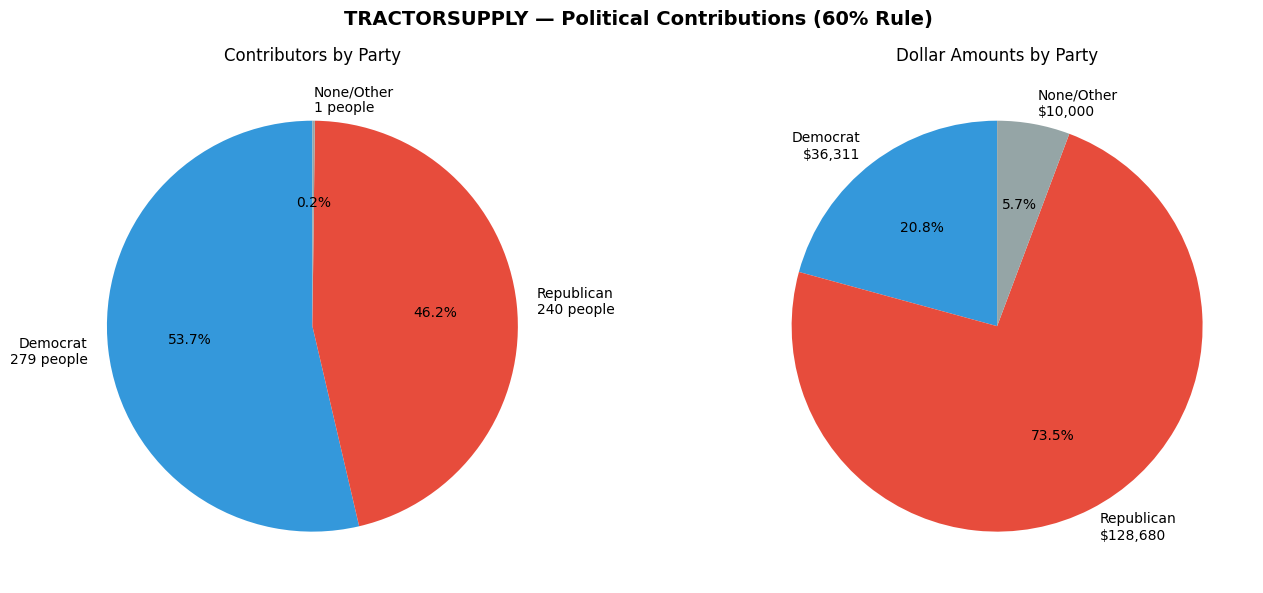

In [9]:
COLOR_MAP = {
    'D': '#3498db', 'R': '#e74c3c', 'N': '#95a5a6',
    'I': '#f39c12', 'L': '#9b59b6', 'G': '#27ae60',
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f'{company_name} — Political Contributions (60% Rule)', fontsize=14, fontweight='bold')

count_labels, counts, count_colors = [], [], []
dollar_labels, dollars, dollar_colors = [], [], []

for _, row in contrib_stats.iterrows():
    name = PARTY_FULL.get(row['pCode'], row['pCode'])
    c    = COLOR_MAP.get(row['pCode'], '#95a5a6')
    count_labels.append(f"{name}\n{row['people_count']:.0f} people")
    counts.append(row['people_count'])
    count_colors.append(c)
    dollar_labels.append(f"{name}\n${row['party_dollars']:,.0f}")
    dollars.append(row['party_dollars'])
    dollar_colors.append(c)

ax1.pie(counts,  labels=count_labels,  colors=count_colors,  autopct='%1.1f%%', startangle=90)
ax1.set_title('Contributors by Party')
ax2.pie(dollars, labels=dollar_labels, colors=dollar_colors, autopct='%1.1f%%', startangle=90)
ax2.set_title('Dollar Amounts by Party')

plt.tight_layout()
plt.show()

## Summary

In [10]:
print('=' * 60)
print(f'Company             : {company_name}')
print(f'Total transactions  : {len(saspac3):,}')
print(f'Total amount        : ${saspac3["amount"].sum():,.2f}')
print(f'Unique contributors : {total_people:,}')
print(f'Avg txns / person   : {len(saspac3) / total_people:.1f}')
print('=' * 60)

Company             : TRACTORSUPPLY
Total transactions  : 3,713
Total amount        : $174,991.63
Unique contributors : 520
Avg txns / person   : 7.1
